# Laboratorio 6

### Luis Pedro Gonzalez | 20236401

In [1]:
# celda 1

import re
import random
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from collections import Counter
from IPython.display import display

random.seed(42)

nlp_segmentar = spacy.blank('en')
nlp_segmentar.add_pipe('sentencizer')

nlp_modelo = spacy.load('en_core_web_sm')


In [2]:
# celda 2

df = pd.read_csv('gutenberg_novels_dataset.csv')

orden_libros = [
    'Pride and Prejudice',
    'Frankenstein',
    'Dracula'
]

df = (
    df.set_index('title')
    .loc[orden_libros]
    .reset_index()
)

anios = {
    'Pride and Prejudice': 1813,
    'Frankenstein': 1818,
    'Dracula': 1897
}

tabla_libros = df[['title', 'author']].copy()

tabla_libros['Año de publicación'] = (
    tabla_libros['title'].map(anios)
)

tabla_libros.columns = [
    'Título',
    'Autor',
    'Año de publicación'
]

tabla_libros

,Título,Autor,Año de publicación
0,Pride and Prejudice,Jane Austen,1813
1,Frankenstein,Mary Shelley,1818
2,Dracula,Bram Stoker,1897


In [3]:
# celda 3

def limpiar_novela(titulo, texto):
    
    if titulo == 'Pride and Prejudice':
        inicio = texto.find(
            'It is a truth universally acknowledged'
        )
        
        fin = texto.find(
            '*** END OF THE PROJECT GUTENBERG EBOOK',
            inicio
        )
    
    elif titulo == 'Frankenstein':
        primer_letter = texto.find('Letter 1')
        
        inicio = texto.find(
            'Letter 1',
            primer_letter + 1
        )
        
        fin = texto.find(
            '*** END OF THE PROJECT GUTENBERG EBOOK',
            inicio
        )
    
    elif titulo == 'Dracula':
        inicio = texto.find(
            'DRACULA\n\nCHAPTER I'
        )
        
        fin = texto.find(
            'THE END',
            inicio
        )
    
    else:
        inicio = 0
        fin = len(texto)
    
    
    if inicio == -1:
        inicio = 0
    
    if fin == -1:
        fin = len(texto)
    
    
    texto = texto[inicio:fin]
    
    # quitar indicaciones de ilustraciones
    texto = re.sub(
        r'\[Illustration.*?\]',
        ' ',
        texto,
        flags=re.DOTALL | re.IGNORECASE
    )
    
    # quitar marcas de cursiva de Gutenberg
    texto = texto.replace('_', '')
    
    # dejar espacios normales
    texto = re.sub(
        r'\s+',
        ' ',
        texto
    ).strip()
    
    return texto


textos_limpios = {}

for _, fila in df.iterrows():
    
    titulo = fila['title']
    texto = fila['text']
    
    textos_limpios[titulo] = limpiar_novela(
        titulo,
        texto
    )
    
    print(titulo)
    print(
        "Caracteres después de limpiar:",
        len(textos_limpios[titulo])
    )
    print()

Pride and Prejudice
Caracteres después de limpiar: 683037

Frankenstein
Caracteres después de limpiar: 417821

Dracula
Caracteres después de limpiar: 834275



In [4]:
# celda 4

datos_libros = {}
muestras = {}

generador = random.Random(42)

for titulo in orden_libros:
    
    texto = textos_limpios[titulo]
    
    nlp_segmentar.max_length = max(
        nlp_segmentar.max_length,
        len(texto) + 1000
    )
    
    doc = nlp_segmentar(texto)
    
    oraciones = []
    candidatas = []
    
    for oracion in doc.sents:
        
        texto_oracion = oracion.text.strip()
        
        if not texto_oracion:
            continue
        
        oraciones.append(texto_oracion)
        
        tokens = [
            token
            for token in oracion
            if not token.is_space
        ]
        
        palabras = sum(
            token.is_alpha
            for token in tokens
        )
        
        # evitar títulos demasiado cortos
        # y oraciones exageradamente largas
        if palabras >= 5 and len(tokens) <= 80:
            candidatas.append(texto_oracion)
    
    
    tokens_totales = sum(
        1
        for token in doc
        if not token.is_space
    )
    
    
    muestra = generador.sample(
        candidatas,
        100
    )
    
    
    datos_libros[titulo] = {
        'oraciones': oraciones,
        'candidatas': candidatas,
        'tokens_totales': tokens_totales
    }
    
    muestras[titulo] = muestra
    
    
    print(titulo)
    print("Oraciones totales:", len(oraciones))
    print("Tokens totales:", tokens_totales)
    print("Oraciones disponibles para muestra:", len(candidatas))
    print("Oraciones seleccionadas:", len(muestra))
    print()

Pride and Prejudice
Oraciones totales: 5943
Tokens totales: 144296
Oraciones disponibles para muestra: 5386
Oraciones seleccionadas: 100

Frankenstein
Oraciones totales: 3316
Tokens totales: 85728
Oraciones disponibles para muestra: 3085
Oraciones seleccionadas: 100

Dracula
Oraciones totales: 8527
Tokens totales: 190147
Oraciones disponibles para muestra: 7611
Oraciones seleccionadas: 100



In [5]:
# celda 5

resumen_muestras = []

for titulo in orden_libros:
    
    tokens_muestra = 0
    
    for oracion in muestras[titulo]:
        
        doc = nlp_segmentar.make_doc(oracion)
        
        tokens_muestra += sum(
            1
            for token in doc
            if not token.is_space
        )
    
    
    resumen_muestras.append([
        titulo,
        len(datos_libros[titulo]['oraciones']),
        datos_libros[titulo]['tokens_totales'],
        len(muestras[titulo]),
        tokens_muestra
    ])


tabla_muestras = pd.DataFrame(
    resumen_muestras,
    columns=[
        'Libro',
        'Oraciones libro completo',
        'Tokens libro completo',
        'Oraciones muestra',
        'Tokens muestra'
    ]
)

tabla_muestras

,Libro,Oraciones libro completo,Tokens libro completo,Oraciones muestra,Tokens muestra
0,Pride and Prejudice,5943,144296,100,2432
1,Frankenstein,3316,85728,100,2920
2,Dracula,8527,190147,100,2427


# Sección 1: preparación de la muestra de trabajo

Las tres novelas tienen tamaños bastante diferentes. Dracula fue la más extensa, con 8,527 oraciones y 190,147 tokens, seguida de Pride and Prejudice con 5,943 oraciones y 144,296 tokens. Frankenstein fue la más corta de las tres, con 3,316 oraciones y 85,728 tokens.

Para trabajar con una cantidad de texto que se pudiera revisar con más detalle, se seleccionaron 100 oraciones aleatorias de cada novela. Las muestras quedaron con 2,432 tokens para Pride and Prejudice, 2,920 para Frankenstein y 2,427 para Dracula.

Aunque se usó la misma cantidad de oraciones para los tres libros, la muestra de Frankenstein terminó teniendo más tokens. Esto indica que, en promedio, las oraciones seleccionadas de Frankenstein fueron un poco más largas.

In [6]:
# celda 6

filas_pos = []
docs_muestra = {}

for titulo in orden_libros:
    
    docs = list(
        nlp_modelo.pipe(
            muestras[titulo],
            batch_size=20
        )
    )
    
    docs_muestra[titulo] = docs
    
    
    for doc in docs:
        
        for token in doc:
            
            if token.is_space or token.is_punct:
                continue
            
            filas_pos.append([
                titulo,
                token.text,
                token.pos_,
                token.tag_,
                doc.text
            ])


df_pos = pd.DataFrame(
    filas_pos,
    columns=[
        'Libro',
        'Token',
        'POS',
        'Penn',
        'Oracion'
    ]
)

df_pos.head(20)

,Libro,Token,POS,Penn,Oracion
0,Pride and Prejudice,I,PRON,PRP,"I shall offer to pay him to-morrow, he will ra..."
1,Pride and Prejudice,shall,AUX,MD,"I shall offer to pay him to-morrow, he will ra..."
2,Pride and Prejudice,offer,VERB,VB,"I shall offer to pay him to-morrow, he will ra..."
3,Pride and Prejudice,to,PART,TO,"I shall offer to pay him to-morrow, he will ra..."
4,Pride and Prejudice,pay,VERB,VB,"I shall offer to pay him to-morrow, he will ra..."
5,Pride and Prejudice,him,PRON,PRP,"I shall offer to pay him to-morrow, he will ra..."
6,Pride and Prejudice,to,ADP,IN,"I shall offer to pay him to-morrow, he will ra..."
7,Pride and Prejudice,morrow,NOUN,NN,"I shall offer to pay him to-morrow, he will ra..."
8,Pride and Prejudice,he,PRON,PRP,"I shall offer to pay him to-morrow, he will ra..."
9,Pride and Prejudice,will,AUX,MD,"I shall offer to pay him to-morrow, he will ra..."


In [7]:
# celda 7

tabla_pos_cantidad = pd.crosstab(
    df_pos['POS'],
    df_pos['Libro']
)

tabla_pos_porcentaje = (
    tabla_pos_cantidad
    .div(
        tabla_pos_cantidad.sum(axis=0),
        axis=1
    )
    * 100
)

print("Cantidad de tokens por categoría:")
display(tabla_pos_cantidad)

print()
print("Distribución porcentual:")
display(
    tabla_pos_porcentaje.round(2)
)

Cantidad de tokens por categoría:


Libro,Dracula,Frankenstein,Pride and Prejudice
POS,,,
ADJ,155,187,116
ADP,243,305,236
ADV,137,128,135
AUX,141,169,176
CCONJ,92,135,86
DET,177,241,159
INTJ,5,1,3
NOUN,316,467,300
NUM,11,9,12



Distribución porcentual:


Libro,Dracula,Frankenstein,Pride and Prejudice
POS,,,
ADJ,7.33,7.25,5.58
ADP,11.48,11.83,11.35
ADV,6.47,4.97,6.49
AUX,6.66,6.56,8.47
CCONJ,4.35,5.24,4.14
DET,8.36,9.35,7.65
INTJ,0.24,0.04,0.14
NOUN,14.93,18.11,14.43
NUM,0.52,0.35,0.58


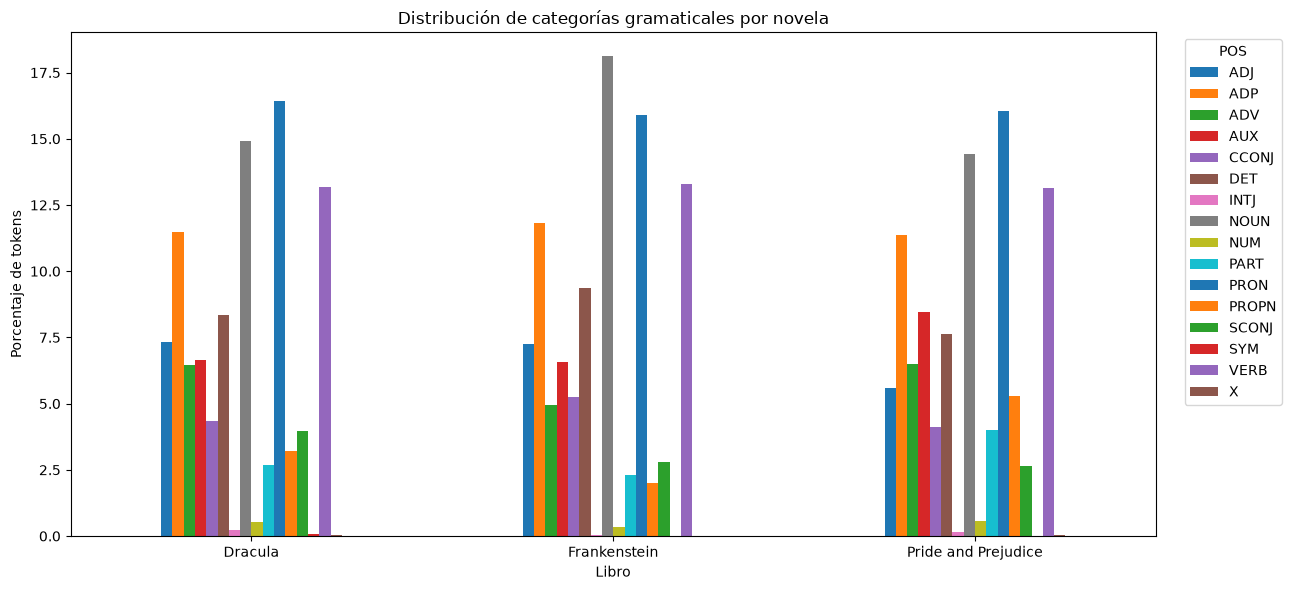

In [8]:
# celda 8

tabla_pos_porcentaje.T.plot(
    kind='bar',
    figsize=(13, 6)
)

plt.xlabel('Libro')
plt.ylabel('Porcentaje de tokens')
plt.title(
    'Distribución de categorías gramaticales por novela'
)

plt.xticks(rotation=0)

plt.legend(
    title='POS',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [9]:
# celda 9

df_palabras = df_pos[
    df_pos['Token'].apply(str.isalpha)
].copy()

df_palabras['Palabra'] = (
    df_palabras['Token'].str.lower()
)


resumen_ambiguedad = (
    df_palabras
    .groupby('Palabra')
    .agg(
        Etiquetas=('POS', 'nunique'),
        Apariciones=('POS', 'size')
    )
)

resumen_ambiguedad = resumen_ambiguedad[
    resumen_ambiguedad['Etiquetas'] >= 2
]

resumen_ambiguedad = resumen_ambiguedad.sort_values(
    ['Apariciones', 'Etiquetas'],
    ascending=False
)

palabras_ambiguas = (
    resumen_ambiguedad
    .head(3)
    .index
    .tolist()
)


for palabra in palabras_ambiguas:
    
    print("=" * 80)
    print("PALABRA:", palabra.upper())
    
    ejemplos = df_palabras[
        df_palabras['Palabra'] == palabra
    ]
    
    for etiqueta in ejemplos['POS'].unique():
        
        ejemplo = ejemplos[
            ejemplos['POS'] == etiqueta
        ].iloc[0]
        
        print()
        print("Libro:", ejemplo['Libro'])
        print("Etiqueta:", etiqueta)
        print("Contexto:")
        print(ejemplo['Oracion'])
    
    print()


print()
print("=" * 80)
print("EJEMPLOS PARA REVISAR EL TAGGER")
print("=" * 80)

for titulo in orden_libros:
    
    print()
    print(titulo.upper())
    
    for doc in docs_muestra[titulo][:2]:
        
        etiquetas = [
            (token.text, token.pos_)
            for token in doc
            if not token.is_space
            and not token.is_punct
        ]
        
        print()
        print(doc.text)
        print(etiquetas)

PALABRA: THE

Libro: Pride and Prejudice
Etiqueta: DET
Contexto:
I shall offer to pay him to-morrow, he will rant and storm about his love for you, and there will be an end of the matter.”

Libro: Dracula
Etiqueta: PRON
Contexto:
For answer he put his hand on my shoulder, and said, with infinite tenderness:-- “Friend John, I pity your poor bleeding heart; and I love you the more because it does so bleed.

PALABRA: TO

Libro: Pride and Prejudice
Etiqueta: PART
Contexto:
I shall offer to pay him to-morrow, he will rant and storm about his love for you, and there will be an end of the matter.”

Libro: Pride and Prejudice
Etiqueta: ADP
Contexto:
I shall offer to pay him to-morrow, he will rant and storm about his love for you, and there will be an end of the matter.”

Libro: Pride and Prejudice
Etiqueta: AUX
Contexto:
He was then, he said, on his way to Longbourn on purpose to inquire after her.

Libro: Dracula
Etiqueta: NOUN
Contexto:
To-night he may talk of himself, if I turn the convers

# Sección 2: etiquetado gramatical POS tagging

### Comparación de la distribución de categorías gramaticales

Las tres novelas tienen distribuciones bastante parecidas en varias categorías, especialmente en verbos y pronombres. Los verbos representan aproximadamente el 13 por ciento de los tokens en los tres libros, mientras que los pronombres están cerca del 16 por ciento.

Una diferencia más visible aparece en los sustantivos. Frankenstein tuvo el porcentaje más alto con 18.11 por ciento, mientras que Dracula obtuvo 14.93 por ciento y Pride and Prejudice 14.43 por ciento.

Por otro lado, Pride and Prejudice tuvo más nombres propios, con 5.29 por ciento, comparado con 3.21 por ciento en Dracula y 2.02 por ciento en Frankenstein. Esto puede deberse a que en Pride and Prejudice aparecen muchos nombres de personajes durante la muestra que se analizó.

También se observa que Dracula y Frankenstein tienen un porcentaje mayor de adjetivos que Pride and Prejudice. Aun así, las diferencias no son demasiado grandes y los tres libros tienen una distribución general bastante parecida.

### Ambigüedad de etiquetas

Entre las palabras que recibieron etiquetas diferentes aparecieron the, to y a.

El caso de to es el que muestra más claramente cómo el contexto puede cambiar la función de una palabra. Por ejemplo, puede funcionar como PART cuando introduce un infinitivo, como en to pay, o como ADP cuando funciona como preposición.

Sin embargo, no todos los cambios de etiqueta parecen ser casos reales de ambigüedad. Por ejemplo, a normalmente funciona como determinante, pero en uno de los ejemplos el modelo la clasificó como pronombre. También aparecieron algunas etiquetas poco comunes para the.

En esos casos parece más probable que se trate de errores del tagger y no de una verdadera diferencia en la función de la palabra.

### Posibles errores del tagger y diferencias entre las novelas

Sí se observaron algunos errores que pueden estar relacionados con la forma de escribir de estas novelas.

Un ejemplo aparece con expresiones antiguas separadas por guion, como to-morrow y To-night. La tokenización separa estas expresiones y el tagger termina analizando algunas partes como si fueran palabras independientes, lo que puede producir etiquetas extrañas.

En los ejemplos revisados no parece haber un libro donde el tagger falle muchísimo más que en los otros. Pride and Prejudice y Dracula sí mostraron varios casos extraños relacionados con construcciones y formas de escritura menos comunes en inglés actual.

Frankenstein presentó menos errores visibles en los ejemplos mostrados, pero la muestra es demasiado pequeña como para decir que el modelo funciona mejor en toda la novela.

Esto tiene sentido porque el modelo fue entrenado principalmente con inglés contemporáneo, mientras que las tres novelas utilizan vocabulario, puntuación y construcciones de otras épocas.

In [10]:
# celda 10

libro_manual = 'Pride and Prejudice'

doc_ejemplo = docs_muestra[
    libro_manual
][6]

tokens_10 = [
    token
    for token in doc_ejemplo
    if not token.is_space
    and not token.is_punct
][:10]


tabla_tagsets = pd.DataFrame({
    'Token': [
        token.text
        for token in tokens_10
    ],
    
    'POS universal': [
        token.pos_
        for token in tokens_10
    ],
    
    'Penn Treebank': [
        token.tag_
        for token in tokens_10
    ]
})

print("Oración utilizada:")
print(doc_ejemplo.text)
print()

tabla_tagsets

Oración utilizada:
She is a handsome girl, about fifteen or sixteen, and, I understand, highly accomplished.



,Token,POS universal,Penn Treebank
0,She,PRON,PRP
1,is,AUX,VBZ
2,a,DET,DT
3,handsome,ADJ,JJ
4,girl,NOUN,NN
5,about,ADV,RB
6,fifteen,NUM,CD
7,or,CCONJ,CC
8,sixteen,NUM,CD
9,and,CCONJ,CC


In [11]:
# celda 11

indices_manual = [
    6,
    7,
    13,
    18,
    19
]

oraciones_manual = [
    muestras[libro_manual][indice]
    for indice in indices_manual
]

for numero, oracion in enumerate(
    oraciones_manual,
    1
):
    print(f"Oración {numero}:")
    print(oracion)
    print()


tags_manuales = [
    
    # Oración 1
    [
        'PRP', 'VBZ', 'DT', 'JJ', 'NN',
        'IN', 'CD', 'CC', 'CD', 'CC',
        'PRP', 'VBP', 'RB', 'JJ'
    ],
    
    # Oración 2
    [
        'UH', 'VBD', 'NNP', 'PRP', 'VBP',
        'VBN', 'DT', 'JJ', 'NN'
    ],
    
    # Oración 3
    [
        'TO', 'VB', 'RB', 'RB', 'JJ'
    ],
    
    # Oración 4
    [
        'PRP', 'VBP', 'RBS', 'RB', 'JJ'
    ],
    
    # Oración 5
    [
        'NNP', 'VBD', 'JJ', 'IN', 'VBG',
        'VBN', 'WRB', 'PRP', 'VBD', 'NNP',
        'VBD', 'RB', 'VBG', 'NN'
    ]
]

print(
    "Las etiquetas manuales ya fueron preparadas."
)

Oración 1:
She is a handsome girl, about fifteen or sixteen, and, I understand, highly accomplished.

Oración 2:
No,” said Darcy, “I have made no such pretension.

Oración 3:
to be only just tolerable.” “

Oración 4:
I am most seriously displeased.”

Oración 5:
Bingley was sure of being liked wherever he appeared; Darcy was continually giving offence.

Las etiquetas manuales ya fueron preparadas.


In [12]:
# celda 12

comparacion_manual = []

for numero, (
    indice,
    etiquetas_manuales
) in enumerate(
    zip(
        indices_manual,
        tags_manuales
    ),
    1
):
    
    doc = docs_muestra[
        libro_manual
    ][indice]
    
    palabras = [
        token
        for token in doc
        if token.is_alpha
    ]
    
    
    if len(palabras) != len(etiquetas_manuales):
        print(
            "Revisar oración",
            numero,
            "- cantidad diferente de tokens."
        )
    
    
    for token, etiqueta_manual in zip(
        palabras,
        etiquetas_manuales
    ):
        
        comparacion_manual.append([
            numero,
            token.text,
            etiqueta_manual,
            token.tag_,
            etiqueta_manual == token.tag_
        ])


tabla_manual = pd.DataFrame(
    comparacion_manual,
    columns=[
        'Oración',
        'Token',
        'Etiqueta manual',
        'Etiqueta automática',
        'Coincide'
    ]
)

tabla_manual

,Oración,Token,Etiqueta manual,Etiqueta automática,Coincide
0,1,She,PRP,PRP,True
1,1,is,VBZ,VBZ,True
2,1,a,DT,DT,True
3,1,handsome,JJ,JJ,True
4,1,girl,NN,NN,True
5,1,about,IN,RB,False
6,1,fifteen,CD,CD,True
7,1,or,CC,CC,True
8,1,sixteen,CD,CD,True
9,1,and,CC,CC,True


In [13]:
# celda 13

total_tokens_manual = len(
    tabla_manual
)

coincidencias = (
    tabla_manual['Coincide'].sum()
)

porcentaje_coincidencia = (
    coincidencias
    / total_tokens_manual
    * 100
)

print(
    "Tokens comparados:",
    total_tokens_manual
)

print(
    "Coincidencias:",
    coincidencias
)

print(
    "Desacuerdos:",
    total_tokens_manual - coincidencias
)

print(
    f"Porcentaje de coincidencia: "
    f"{porcentaje_coincidencia:.2f}%"
)


print()
print("Tokens donde hubo desacuerdo:")

desacuerdos_pos = tabla_manual[
    tabla_manual['Coincide'] == False
]

desacuerdos_pos

Tokens comparados: 47
Coincidencias: 46
Desacuerdos: 1
Porcentaje de coincidencia: 97.87%

Tokens donde hubo desacuerdo:


,Oración,Token,Etiqueta manual,Etiqueta automática,Coincide
5,1,about,IN,RB,False


# Sección 3: tagsets y anotación

### Diferencia entre el tagset universal y Penn Treebank

El tagset universal da una categoría general para cada palabra, mientras que Penn Treebank da información más específica. Por ejemplo, She aparece como PRON en el tagset universal, pero como PRP en Penn Treebank, indicando que es un pronombre personal. De la misma forma, is aparece como AUX en el tagset universal, mientras que Penn Treebank lo etiqueta como VBZ, dando más información sobre la forma verbal.

Otros ejemplos son fifteen, que pasa de NUM a CD, y handsome, que pasa de ADJ a JJ. En general, el tagset universal es más fácil de interpretar porque utiliza categorías amplias, mientras que Penn Treebank permite ver con más detalle la función gramatical de cada token.

### Comparación entre la anotación manual y el tagger

En las cinco oraciones seleccionadas se compararon 47 tokens. La anotación manual coincidió con el tagger automático en 46 de ellos, dando un porcentaje de coincidencia de 97.87 por ciento. El resultado fue bastante alto y muestra que, al menos para estas cinco oraciones, el tagger identificó correctamente casi todas las etiquetas de Penn Treebank.

### Análisis de los desacuerdos

El único desacuerdo apareció con la palabra about en la frase about fifteen or sixteen. Manualmente se había etiquetado como IN, mientras que el modelo utilizó RB. Al revisar el contexto, la etiqueta RB del modelo tiene bastante sentido porque about significa aproximadamente y está modificando la cantidad fifteen or sixteen.

Por eso, este caso parece ser más una diferencia de criterio en la anotación manual que un error claro del modelo. También muestra que incluso al hacer el etiquetado manual pueden existir palabras donde la categoría no es tan obvia y depende bastante del contexto de la oración.

In [14]:
# celda 14

filas_entidades = []
resumen_fragmentos = []
docs_ner = {}

for titulo in orden_libros:
    
    fragmento = (
        datos_libros[titulo]['candidatas'][:250]
    )
    
    docs = list(
        nlp_modelo.pipe(
            fragmento,
            batch_size=20
        )
    )
    
    docs_ner[titulo] = docs
    
    
    tokens_fragmento = sum(
        1
        for doc in docs
        for token in doc
        if not token.is_space
    )
    
    
    cantidad_entidades = 0
    
    for doc in docs:
        
        for entidad in doc.ents:
            
            cantidad_entidades += 1
            
            filas_entidades.append([
                titulo,
                entidad.text.strip(),
                entidad.label_
            ])
    
    
    resumen_fragmentos.append([
        titulo,
        len(fragmento),
        tokens_fragmento,
        cantidad_entidades
    ])


entidades_df = pd.DataFrame(
    filas_entidades,
    columns=[
        'Libro',
        'Entidad',
        'Tipo'
    ]
)


tabla_tipos_ner = pd.crosstab(
    entidades_df['Tipo'],
    entidades_df['Libro']
)

tabla_tipos_ner.loc['TOTAL'] = (
    tabla_tipos_ner.sum()
)

tabla_tipos_ner

Libro,Dracula,Frankenstein,Pride and Prejudice
Tipo,,,
CARDINAL,18,19,31
DATE,13,39,11
FAC,5,0,3
GPE,22,19,11
LANGUAGE,2,2,0
LAW,1,1,0
LOC,11,4,0
MONEY,0,0,1
NORP,16,3,0


In [15]:
# celda 15

for titulo in orden_libros:
    
    datos = entidades_df[
        entidades_df['Libro'] == titulo
    ]
    
    
    personas = Counter(
        datos[
            datos['Tipo'] == 'PERSON'
        ]['Entidad']
    )
    
    
    lugares = Counter(
        datos[
            datos['Tipo'].isin(
                ['GPE', 'LOC']
            )
        ]['Entidad']
    )
    
    
    print("=" * 70)
    print(titulo.upper())
    
    print()
    print("10 PERSON más frecuentes:")
    
    for entidad, cantidad in personas.most_common(10):
        print(
            f"{entidad}: {cantidad}"
        )
    
    
    print()
    print("10 GPE/LOC más frecuentes:")
    
    for entidad, cantidad in lugares.most_common(10):
        print(
            f"{entidad}: {cantidad}"
        )
    
    print()

PRIDE AND PREJUDICE

10 PERSON más frecuentes:
Bingley: 29
Bennet: 26
Darcy: 14
Lizzy: 8
Jane: 7
Elizabeth: 7
Long: 6
Hurst: 5
Lady Lucas: 4
Kitty: 3

10 GPE/LOC más frecuentes:
Netherfield: 3
London: 2
Charlotte: 2
Lydia: 1
Hertfordshire: 1
England: 1
Meryton: 1

FRANKENSTEIN

10 PERSON más frecuentes:
Margaret: 6
Saville: 2
Petersburgh: 1
Uncle Thomas: 1
Shakespeare: 1
Archangel: 1
R. Walton Letter: 1
Uncle: 1
Robert Walton Letter: 1
Walton: 1

10 GPE/LOC más frecuentes:
Beaufort: 5
England: 4
Archangel: 3
St. Petersburgh: 2
London: 1
the North Pacific Ocean: 1
the North Sea: 1
Greenland: 1
Russia: 1
Africa: 1

DRACULA

10 PERSON más frecuentes:
Herr: 3
JONATHAN HARKER: 2
Count Dracula: 2
Dracula: 2
DRACULA CHAPTER: 1
Danube: 1
the Castle Dracula: 1
Wallachs: 1
Szekelys: 1
Jonathan Harker: 1

10 GPE/LOC más frecuentes:
Bukovina: 6
London: 5
Transylvania: 3
West: 2
East: 2
Slovaks: 2
Vienna: 1
Klausenburgh: 1
Moldavia: 1
Europe: 1



,Libro,Oraciones del fragmento,Tokens del fragmento,Entidades detectadas,Entidades por 100 tokens
0,Pride and Prejudice,250,5669,234,4.13
1,Frankenstein,250,7042,126,1.79
2,Dracula,250,7318,151,2.06


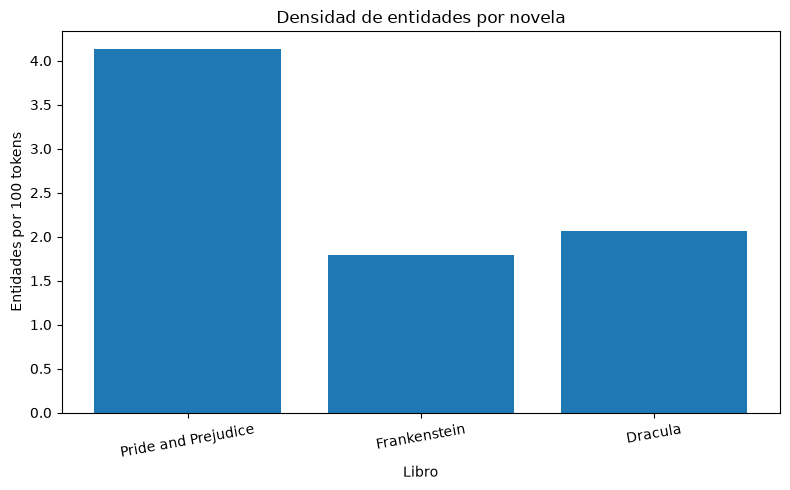

In [16]:
# celda 16

tabla_densidad = pd.DataFrame(
    resumen_fragmentos,
    columns=[
        'Libro',
        'Oraciones del fragmento',
        'Tokens del fragmento',
        'Entidades detectadas'
    ]
)

tabla_densidad[
    'Entidades por 100 tokens'
] = (
    tabla_densidad[
        'Entidades detectadas'
    ]
    / tabla_densidad[
        'Tokens del fragmento'
    ]
    * 100
)

display(
    tabla_densidad.round(2)
)


plt.figure(figsize=(8, 5))

plt.bar(
    tabla_densidad['Libro'],
    tabla_densidad[
        'Entidades por 100 tokens'
    ]
)

plt.xlabel('Libro')
plt.ylabel('Entidades por 100 tokens')
plt.title(
    'Densidad de entidades por novela'
)

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# Sección 4: reconocimiento de entidades nombradas NER

### Distribución de entidades entre las novelas

El modelo detectó 234 entidades en el fragmento de Pride and Prejudice, 126 en Frankenstein y 151 en Dracula. La diferencia más grande aparece en las entidades de tipo PERSON. En Pride and Prejudice se detectaron 133, mientras que en Frankenstein fueron 18 y en Dracula 24.

También hay diferencias en otros tipos de entidades. Frankenstein tuvo bastantes entidades DATE, con 39, mientras que Dracula presentó una mezcla más variada entre PERSON, GPE, ORG y NORP. Esto muestra que no solamente cambia la cantidad de entidades entre las novelas, sino también los tipos que aparecen con mayor frecuencia.

### PERSON y GPE LOC más frecuentes

En Pride and Prejudice, varios de los nombres detectados con mayor frecuencia sí corresponden a personajes importantes, como Bingley, Bennet, Darcy, Lizzy, Jane y Elizabeth. Entre los lugares también aparecen correctamente Netherfield, London, Hertfordshire, England y Meryton. Sin embargo, también se observan errores. Por ejemplo, Charlotte y Lydia son personajes, pero el modelo las clasificó como lugares.

En Frankenstein aparecen nombres como Margaret y Walton, además de lugares como England, St. Petersburgh, London, Greenland y Russia. También hay errores claros. Beaufort aparece entre los lugares más frecuentes aunque corresponde a una persona, y R. Walton Letter tampoco representa correctamente una persona.

En Dracula aparecen correctamente Jonathan Harker y Count Dracula entre las personas, y lugares como Bukovina, London, Transylvania, Vienna y Europe. También se encuentran errores como Danube, que fue clasificado como persona, y términos como Wallachs y Szekelys, que el modelo también clasificó de forma incorrecta.

En Pride and Prejudice solamente aparecieron siete entidades diferentes clasificadas como GPE o LOC dentro de este fragmento, por lo que no fue posible mostrar diez lugares distintos.

### Densidad de entidades

Pride and Prejudice tuvo la mayor densidad, con 4.13 entidades por cada 100 tokens. Dracula quedó en segundo lugar con 2.06 y Frankenstein tuvo la menor densidad con 1.79 entidades por cada 100 tokens. Esto puede deberse a que en Pride and Prejudice aparecen muchos nombres de personajes durante el fragmento analizado.

### Relación con los personajes, lugares y estilo de cada novela

Los resultados muestran algunas diferencias entre los libros. Pride and Prejudice parece estar más enfocada en personajes identificados por nombre, ya que tuvo una cantidad bastante mayor de entidades PERSON. Frankenstein tuvo menos nombres propios dentro del fragmento analizado, mientras que Dracula quedó en un punto intermedio y presentó una mezcla más variada de personas, lugares y otros tipos de entidades.

De todas formas, estos resultados también están afectados por los errores del modelo. Algunos nombres de personas fueron confundidos con lugares u organizaciones, por lo que no todas las diferencias se pueden atribuir solamente al estilo de cada novela.

In [17]:
# celda 17

indices_bio = [
    15,
    16,
    17,
    18,
    19
]

oraciones_bio = [
    muestras[
        'Pride and Prejudice'
    ][indice]
    for indice in indices_bio
]


entidades_bio_manual = [
    
    # Oración 1
    [
        ('Jane', 'PERSON')
    ],
    
    # Oración 2
    [
        ('Derbyshire', 'GPE')
    ],
    
    # Oración 3
    [
        ('Mr. Bennet', 'PERSON')
    ],
    
    # Oración 4
    [],
    
    # Oración 5
    [
        ('Bingley', 'PERSON'),
        ('Darcy', 'PERSON')
    ]
]


for numero, (
    oracion,
    entidades_correctas
) in enumerate(
    zip(
        oraciones_bio,
        entidades_bio_manual
    ),
    1
):
    
    doc = nlp_modelo(oracion)
    
    entidades_modelo = [
        (ent.text, ent.label_)
        for ent in doc.ents
    ]
    
    
    print(f"ORACIÓN {numero}")
    print(oracion)
    
    print(
        "Entidades del modelo:",
        entidades_modelo
    )
    
    print(
        "Entidades después de revisión manual:",
        entidades_correctas
    )
    
    print()

ORACIÓN 1
I must think your language too strong in speaking of both,” replied Jane; “and I hope you will be convinced of it, by seeing them happy together.
Entidades del modelo: [('Jane', 'PERSON')]
Entidades después de revisión manual: [('Jane', 'PERSON')]

ORACIÓN 2
About ten or a dozen years ago, before her marriage, she had spent a considerable time in that very part of Derbyshire to which he belonged.
Entidades del modelo: [('About ten or a dozen years ago', 'CARDINAL'), ('Derbyshire', 'ORG')]
Entidades después de revisión manual: [('Derbyshire', 'GPE')]

ORACIÓN 3
To Mr. Bennet’s acknowledgments he briefly replied, with assurances of his eagerness to promote the welfare of any of his family; and concluded with entreaties that the subject might never be mentioned to him again.
Entidades del modelo: [('Bennet', 'PERSON')]
Entidades después de revisión manual: [('Mr. Bennet', 'PERSON')]

ORACIÓN 4
I am most seriously displeased.”
Entidades del modelo: []
Entidades después de revisió

In [18]:
# celda 18

tokens_bio = []
etiquetas_bio = []


for oracion, entidades in zip(
    oraciones_bio,
    entidades_bio_manual
):
    
    doc = nlp_modelo.make_doc(
        oracion
    )
    
    tokens = [
        token
        for token in doc
        if not token.is_space
    ]
    
    etiquetas = [
        'O'
        for token in tokens
    ]
    
    
    for texto_entidad, tipo in entidades:
        
        inicio = oracion.find(
            texto_entidad
        )
        
        fin = (
            inicio
            + len(texto_entidad)
        )
        
        
        posiciones = []
        
        for i, token in enumerate(tokens):
            
            inicio_token = token.idx
            fin_token = (
                token.idx
                + len(token.text)
            )
            
            if (
                inicio_token < fin
                and fin_token > inicio
            ):
                posiciones.append(i)
        
        
        for j, posicion in enumerate(
            posiciones
        ):
            
            if j == 0:
                etiquetas[posicion] = (
                    'B-' + tipo
                )
            
            else:
                etiquetas[posicion] = (
                    'I-' + tipo
                )
    
    
    tokens_bio.extend(
        [token.text for token in tokens]
    )
    
    etiquetas_bio.extend(
        etiquetas
    )


tabla_bio = pd.DataFrame(
    [
        tokens_bio,
        etiquetas_bio
    ],
    index=[
        'Token',
        'BIO'
    ]
)

tabla_bio.columns = range(
    1,
    len(tokens_bio) + 1
)

tabla_bio

,1,2,3,4,5,6,7,8,9,10,...,115,116,117,118,119,120,121,122,123,124
Token,I,must,think,your,language,too,strong,in,speaking,of,...,wherever,he,appeared,;,Darcy,was,continually,giving,offence,.
BIO,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,B-PERSON,O,O,O,O,O


# Sección 5: esquema BIO

La tabla de arriba muestra el etiquetado BIO realizado token por token. Se utilizaron las entidades detectadas por el modelo como punto de partida y se corrigieron manualmente los casos necesarios. Por ejemplo, Derbyshire se corrigió a GPE y Bennet se amplió a Mr. Bennet para conservar la entidad completa.

In [19]:
# celda 19

tipos_evaluados = {
    'PERSON',
    'GPE',
    'LOC',
    'ORG',
    'NORP'
}


oraciones_evaluacion = {
    titulo: muestras[titulo][:20]
    for titulo in orden_libros
}


gold_manual = {
    
    'Pride and Prejudice': [
        
        [],
        
        [
            ('Lady Catherine', 'PERSON')
        ],
        
        [
            ('England', 'GPE')
        ],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [
            ('Darcy', 'PERSON')
        ],
        
        [],
        
        [],
        
        [
            ('Lady Catherine', 'PERSON')
        ],
        
        [
            ('Mr. and Mrs. Gardiner', 'PERSON')
        ],
        
        [],
        
        [],
        
        [],
        
        [
            ('Jane', 'PERSON')
        ],
        
        [
            ('Derbyshire', 'GPE')
        ],
        
        [
            ('Mr. Bennet', 'PERSON')
        ],
        
        [],
        
        [
            ('Bingley', 'PERSON'),
            ('Darcy', 'PERSON')
        ]
    ],
    
    
    'Frankenstein': [
        
        [],
        
        [],
        
        [
            ('Elizabeth', 'PERSON')
        ],
        
        [
            ('Turk', 'NORP'),
            ('Felix', 'PERSON'),
            ('Italy', 'GPE'),
            ('Safie', 'PERSON'),
            ('Leghorn', 'GPE'),
            ('Arabian', 'NORP'),
            ('Paris', 'GPE'),
            ('De Lacey', 'PERSON'),
            ('Agatha', 'PERSON')
        ],
        
        [],
        
        [],
        
        [
            ('Elizabeth', 'PERSON'),
            ('Ingolstadt', 'GPE')
        ],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [
            ('Italy', 'GPE'),
            ('Leghorn', 'GPE'),
            ('Turkey', 'GPE'),
            ('Germany', 'GPE')
        ],
        
        []
    ],
    
    
    'Dracula': [
        
        [],
        
        [
            ('Scotland', 'GPE')
        ],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [],
        
        [
            ('John', 'PERSON')
        ],
        
        [],
        
        [],
        
        [],
        
        [
            ('Dr. Van Helsing', 'PERSON')
        ],
        
        [],
        
        [],
        
        [
            ('Van Helsing', 'PERSON'),
            ('Mina', 'PERSON')
        ],
        
        [
            ('Lucy Westenra', 'PERSON'),
            ('Mina Murray', 'PERSON')
        ],
        
        [
            ('Arthur', 'PERSON')
        ]
    ]
}


for titulo in orden_libros:
    
    print(
        titulo,
        "- oraciones:",
        len(oraciones_evaluacion[titulo]),
        "- anotaciones:",
        len(gold_manual[titulo])
    )

Pride and Prejudice - oraciones: 20 - anotaciones: 20
Frankenstein - oraciones: 20 - anotaciones: 20
Dracula - oraciones: 20 - anotaciones: 20


In [20]:
# celda 20

def convertir_gold(
    oracion,
    entidades
):
    
    spans = []
    
    for texto_entidad, tipo in entidades:
        
        inicio = oracion.find(
            texto_entidad
        )
        
        if inicio == -1:
            raise ValueError(
                f"No se encontró "
                f"'{texto_entidad}' "
                f"en la oración."
            )
        
        fin = (
            inicio
            + len(texto_entidad)
        )
        
        spans.append(
            (
                inicio,
                fin,
                tipo,
                texto_entidad
            )
        )
    
    return spans


docs_evaluacion = {}
gold_spans = {}
pred_spans = {}


for titulo in orden_libros:
    
    docs = list(
        nlp_modelo.pipe(
            oraciones_evaluacion[titulo]
        )
    )
    
    docs_evaluacion[titulo] = docs
    
    gold_spans[titulo] = []
    pred_spans[titulo] = []
    
    filas_revision = []
    
    
    for numero, (
        oracion,
        entidades_manuales,
        doc
    ) in enumerate(
        zip(
            oraciones_evaluacion[titulo],
            gold_manual[titulo],
            docs
        ),
        1
    ):
        
        gold = convertir_gold(
            oracion,
            entidades_manuales
        )
        
        
        pred = [
            (
                ent.start_char,
                ent.end_char,
                ent.label_,
                ent.text
            )
            for ent in doc.ents
            if ent.label_
            in tipos_evaluados
        ]
        
        
        gold_spans[titulo].append(
            gold
        )
        
        pred_spans[titulo].append(
            pred
        )
        
        
        filas_revision.append([
            numero,
            oracion,
            [
                (x[3], x[2])
                for x in gold
            ],
            [
                (x[3], x[2])
                for x in pred
            ]
        ])
    
    
    tabla_revision = pd.DataFrame(
        filas_revision,
        columns=[
            '#',
            'Oración',
            'Gold manual',
            'Predicción spaCy'
        ]
    )
    
    
    print()
    print("=" * 80)
    print(titulo.upper())
    
    display(tabla_revision)


PRIDE AND PREJUDICE


,#,Oración,Gold manual,Predicción spaCy
0,1,"I shall offer to pay him to-morrow, he will ra...",[],[]
1,2,He seems to be a most conscientious and polite...,"[(Lady Catherine, PERSON)]","[(Lady Catherine, PERSON)]"
2,3,They were of a respectable family in the north...,"[(England, GPE)]","[(England, GPE)]"
3,4,Now and then they were honoured with a call fr...,[],[]
4,5,"Her heart had been but slightly touched, and h...",[],[]
5,6,"It is something to think of, and gives her a s...",[],[]
6,7,"She is a handsome girl, about fifteen or sixte...",[],[]
7,8,"No,” said Darcy, “I have made no such pretension.","[(Darcy, PERSON)]","[(Darcy, PERSON)]"
8,9,"Tis an etiquette I despise,” said he. “",[],[]
9,10,To yield readily--easily--to the persuasion of...,[],[]



FRANKENSTEIN


,#,Oración,Gold manual,Predicción spaCy
0,1,"A flash of lightning illuminated the object, a...",[],[]
1,2,The magistrate listened to me with attention a...,[],[]
2,3,"For myself, there was one reward I promised my...","[(Elizabeth, PERSON)]","[(Elizabeth, PERSON)]"
3,4,He quickly arranged with the Turk that if the ...,"[(Turk, NORP), (Felix, PERSON), (Italy, GPE), ...","[(Turk, PERSON), (Felix, ORG), (Italy, GPE), (..."
4,5,For a moment only did I lose recollection; I f...,[],[]
5,6,"Let me go, or I will tell my papa.’ “‘",[],[]
6,7,"I thought I saw Elizabeth, in the bloom of hea...","[(Elizabeth, PERSON), (Ingolstadt, GPE)]","[(Elizabeth, PERSON), (Ingolstadt, GPE)]"
7,8,"Live, and be happy, and make others so.”",[],[]
8,9,Sometimes I grew alarmed at the wreck I percei...,[],[]
9,10,My own agitation and anguish was extreme durin...,[],[]



DRACULA


,#,Oración,Gold manual,Predicción spaCy
0,1,"Then tears come; and, like the rain on the rop...",[],[]
1,2,"Once we saw a man, who seemed not quite sober,...","[(Scotland, GPE)]","[(Scotland, GPE)]"
2,3,This boy will some day know what a brave and g...,[],[]
3,4,She laid her hand on mine and said very gravel...,[],[]
4,5,"I fear what her dreams might be like, with suc...",[],[]
5,6,First we opened the shutters of the window whi...,[],[]
6,7,The Professor held up his little golden crucif...,[],[]
7,8,"It was in a sort of fury, with its eyes savage...",[],[]
8,9,Your police must indeed be zealous men and cle...,[],[]
9,10,"I put him in your window, I make pretty wreath...",[],[]


In [21]:
# celda 21

def calcular_prf(tp, fp, fn):
    
    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)
    
    
    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)
    
    
    if precision + recall == 0:
        f1 = 0
    else:
        f1 = (
            2
            * precision
            * recall
            / (precision + recall)
        )
    
    
    return precision, recall, f1



def bio_para_doc(
    doc,
    spans
):
    
    etiquetas = [
        'O'
        for token in doc
    ]
    
    
    for inicio, fin, tipo, texto in spans:
        
        posiciones = []
        
        for i, token in enumerate(doc):
            
            if token.is_space:
                continue
            
            inicio_token = token.idx
            fin_token = (
                token.idx
                + len(token.text)
            )
            
            if (
                inicio_token < fin
                and fin_token > inicio
            ):
                posiciones.append(i)
        
        
        for j, posicion in enumerate(
            posiciones
        ):
            
            if j == 0:
                etiquetas[posicion] = (
                    'B-' + tipo
                )
            
            else:
                etiquetas[posicion] = (
                    'I-' + tipo
                )
    
    
    return etiquetas



def evaluar_libro(titulo):
    
    tp_token = 0
    fp_token = 0
    fn_token = 0
    
    
    gold_entidades = set()
    pred_entidades = set()
    
    
    for numero, (
        doc,
        gold,
        pred
    ) in enumerate(
        zip(
            docs_evaluacion[titulo],
            gold_spans[titulo],
            pred_spans[titulo]
        )
    ):
        
        gold_bio = bio_para_doc(
            doc,
            gold
        )
        
        pred_bio = bio_para_doc(
            doc,
            pred
        )
        
        
        for real, predicho in zip(
            gold_bio,
            pred_bio
        ):
            
            if (
                real == predicho
                and real != 'O'
            ):
                tp_token += 1
            
            else:
                
                if predicho != 'O':
                    fp_token += 1
                
                if real != 'O':
                    fn_token += 1
        
        
        for inicio, fin, tipo, texto in gold:
            gold_entidades.add(
                (
                    numero,
                    inicio,
                    fin,
                    tipo
                )
            )
        
        
        for inicio, fin, tipo, texto in pred:
            pred_entidades.add(
                (
                    numero,
                    inicio,
                    fin,
                    tipo
                )
            )
    
    
    precision_token, recall_token, f1_token = (
        calcular_prf(
            tp_token,
            fp_token,
            fn_token
        )
    )
    
    
    tp_entidad = len(
        gold_entidades
        & pred_entidades
    )
    
    fp_entidad = len(
        pred_entidades
        - gold_entidades
    )
    
    fn_entidad = len(
        gold_entidades
        - pred_entidades
    )
    
    
    precision_entidad, recall_entidad, f1_entidad = (
        calcular_prf(
            tp_entidad,
            fp_entidad,
            fn_entidad
        )
    )
    
    
    return {
        'token': [
            precision_token,
            recall_token,
            f1_token
        ],
        
        'entidad': [
            precision_entidad,
            recall_entidad,
            f1_entidad
        ]
    }

In [22]:
# celda 22

resultados_metricas = []

for titulo in orden_libros:
    
    resultado = evaluar_libro(
        titulo
    )
    
    
    resultados_metricas.append([
        titulo,
        'Token',
        resultado['token'][0],
        resultado['token'][1],
        resultado['token'][2]
    ])
    
    
    resultados_metricas.append([
        titulo,
        'Entidad completa',
        resultado['entidad'][0],
        resultado['entidad'][1],
        resultado['entidad'][2]
    ])


tabla_metricas = pd.DataFrame(
    resultados_metricas,
    columns=[
        'Libro',
        'Nivel',
        'Precisión',
        'Recall',
        'F1'
    ]
)

tabla_metricas[
    ['Precisión', 'Recall', 'F1']
] = (
    tabla_metricas[
        ['Precisión', 'Recall', 'F1']
    ]
    .round(3)
)

tabla_metricas

,Libro,Nivel,Precisión,Recall,F1
0,Pride and Prejudice,Token,0.750,0.562,0.643
1,Pride and Prejudice,Entidad completa,0.700,0.700,0.700
2,Frankenstein,Token,0.647,0.647,0.647
3,Frankenstein,Entidad completa,0.625,0.625,0.625
4,Dracula,Token,0.917,0.846,0.880
5,Dracula,Entidad completa,0.875,0.875,0.875


# Sección 6: evaluación de entidades

Para la evaluación manual se trabajó con los tipos PERSON, GPE, LOC, ORG y NORP, ya que son los tipos más relacionados con personajes, lugares, organizaciones y grupos mencionados en las novelas. Se utilizaron 20 oraciones de cada libro y las entidades anotadas manualmente se tomaron como referencia para comparar las predicciones del modelo.

### Comparación de precisión, recall y F1

Los resultados muestran diferencias claras entre las tres novelas. Dracula obtuvo el mejor desempeño, con un F1 de 0.880 a nivel de token y 0.875 a nivel de entidad completa. En Frankenstein, el F1 fue de 0.647 por token y 0.625 por entidad completa. Para Pride and Prejudice, el F1 fue de 0.643 por token y 0.700 por entidad completa.

Esto muestra que el desempeño del mismo modelo puede cambiar bastante dependiendo del texto que se esté analizando. En este caso, Dracula fue el libro donde el modelo tuvo mejores resultados.

### Evaluación por token vs evaluación por entidad completa

En estos resultados, la evaluación por token no fue más alta en los tres libros. En Frankenstein y Dracula el F1 por token fue un poco mayor que el F1 por entidad completa. En Pride and Prejudice ocurrió lo contrario. El F1 por token fue 0.643 y por entidad completa fue 0.700.

Esto puede pasar porque la evaluación por token también toma en cuenta las etiquetas BIO exactas. Cuando el modelo detecta solamente una parte de un nombre, puede cambiar dónde aparecen las etiquetas B e I y causar varios desacuerdos a nivel de token. Por lo tanto, aunque la evaluación por token puede dar crédito cuando parte de una entidad fue detectada correctamente, eso no significa que siempre vaya a producir una métrica mayor.

### Diferencias de desempeño entre las tres novelas

Dracula fue el libro donde el modelo obtuvo los mejores resultados. Alcanzó una precisión de 0.917 y un recall de 0.846 a nivel de token, además de un F1 de 0.875 para entidades completas. Frankenstein obtuvo un F1 de 0.625 a nivel de entidad completa. Pride and Prejudice obtuvo 0.700 en esa misma evaluación, aunque su resultado por token fue un poco menor que el de Frankenstein.

También hay que tomar en cuenta que las 20 oraciones de cada libro no contienen la misma cantidad ni la misma dificultad de entidades. Por ejemplo, la muestra de Frankenstein contiene varias entidades diferentes concentradas en algunas oraciones, mientras que la de Dracula tiene menos casos y muchos fueron reconocidos correctamente. Por eso, estas métricas sirven para comparar las muestras utilizadas, pero no necesariamente representan el comportamiento del modelo en toda la novela.

### Errores observados en cada libro

En Pride and Prejudice varios errores estuvieron relacionados con los límites de las entidades. Por ejemplo, el gold standard contenía Mr. and Mrs. Gardiner, pero el modelo solamente detectó Gardiner. Algo parecido ocurrió con Mr. Bennet, donde el modelo detectó solamente Bennet. También clasificó Derbyshire como ORG cuando debía ser GPE.

En Frankenstein se encontraron más confusiones entre tipos de entidad. Por ejemplo, Turk fue tratado como PERSON en lugar de NORP, Felix fue clasificado como ORG en lugar de PERSON y Leghorn, que corresponde a un lugar, fue clasificado como NORP.

En Dracula las predicciones coincidieron en la mayoría de los casos. Uno de los errores fue Dr. Van Helsing, ya que el modelo reconoció solamente Van Helsing. Esto ayuda a entender por qué Dracula terminó obteniendo las mejores métricas de las tres muestras.